<a href="https://colab.research.google.com/github/tmtalebieu2024-cloud/ml-assignment-1-bank-marketing/blob/main/ml_assignment_1_bank_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GitHub repository: https://github.com/tmtalebieu2024-cloud/ml-assignment-1-bank-marketing

IE Machine Learning – Assignment 1
UCI Bank Marketing Dataset

Section 1: Identifying the prediction target

The objective of this assignment is to predict whether a client subscribes to a term deposit during a telemarketing campaign.

The appropriate target variable is **`y`**, which takes the values:
- "yes" → the client subscribed;
- "no" → the client did not subscribe.

This variable directly encodes the business objective of the marketing campaign. The goal is to predict subscription at the time of contact, using information available before or during the call.

Other variables may appear predictive but should not be treated as targets. For example:

- `duration`: represents the length of the call. This is only known after the interaction has ended and therefore cannot be used as a prediction objective.
- `campaign`: represents the number of contacts already performed during the campaign. This reflects campaign history, not the outcome of interest.

Therefore, `y` is the only variable that correctly represents the prediction objective in this context.

Section 2: Data loading and exploration

In [42]:
import os
os.listdir()

['.config',
 'bank.zip',
 'bank-additional.zip',
 'bank_marketing',
 'bank+marketing.zip',
 'sample_data']

In [43]:
import zipfile

with zipfile.ZipFile("bank+marketing.zip", "r") as zip_ref:
    zip_ref.extractall()

In [44]:
os.listdir()

['.config',
 'bank.zip',
 'bank-additional.zip',
 'bank_marketing',
 'bank+marketing.zip',
 'sample_data']

In [45]:
import zipfile

with zipfile.ZipFile("bank-additional.zip", "r") as zip_ref:
    zip_ref.extractall("bank_marketing")

In [46]:
os.listdir("bank_marketing")

['bank-additional', '__MACOSX']

In [47]:
os.listdir("bank_marketing/bank-additional")

['bank-additional.csv',
 'bank-additional-full.csv',
 'bank-additional-names.txt',
 '.Rhistory',
 '.DS_Store']

In [48]:
import pandas as pd
df = pd.read_csv("bank_marketing/bank-additional/bank-additional.csv", sep=";")
df.shape

(4119, 21)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [50]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [51]:
df["y"].value_counts()
df["y"].value_counts(normalize=True)

,proportion
y,
no,0.890507
yes,0.109493


In [52]:
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical variables:")
print(categorical_cols)

print("\nNumerical variables:")
print(numerical_cols)

Categorical variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

Numerical variables:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [53]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [54]:
for col in categorical_cols:
    print(col, df[col].unique())

job ['blue-collar' 'services' 'admin.' 'entrepreneur' 'self-employed'
 'technician' 'management' 'student' 'retired' 'housemaid' 'unemployed'
 'unknown']
marital ['married' 'single' 'divorced' 'unknown']
education ['basic.9y' 'high.school' 'university.degree' 'professional.course'
 'basic.6y' 'basic.4y' 'unknown' 'illiterate']
default ['no' 'unknown' 'yes']
housing ['yes' 'no' 'unknown']
loan ['no' 'unknown' 'yes']
contact ['cellular' 'telephone']
month ['may' 'jun' 'nov' 'sep' 'jul' 'aug' 'mar' 'oct' 'apr' 'dec']
day_of_week ['fri' 'wed' 'mon' 'thu' 'tue']
poutcome ['nonexistent' 'failure' 'success']
y ['no' 'yes']


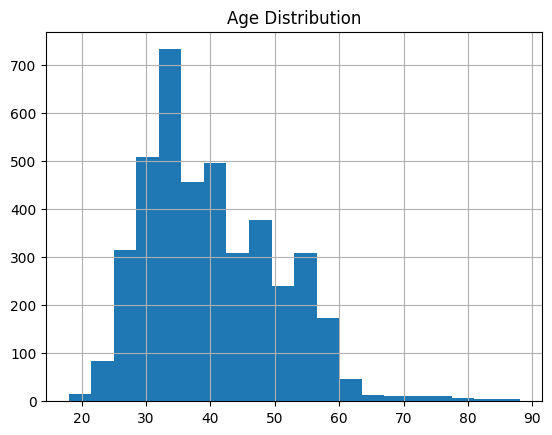

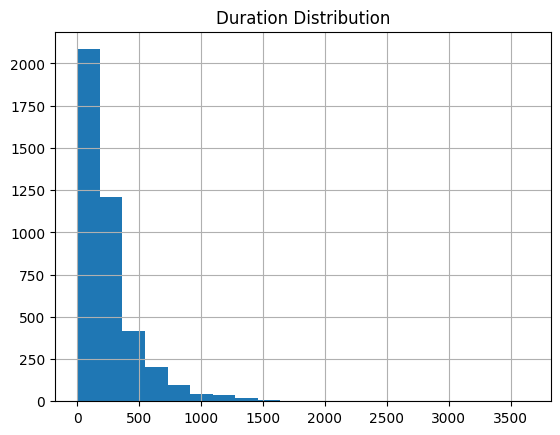

In [55]:
import matplotlib.pyplot as plt

df["age"].hist(bins=20)
plt.title("Age Distribution")
plt.show()

df["duration"].hist(bins=20)
plt.title("Duration Distribution")
plt.show()

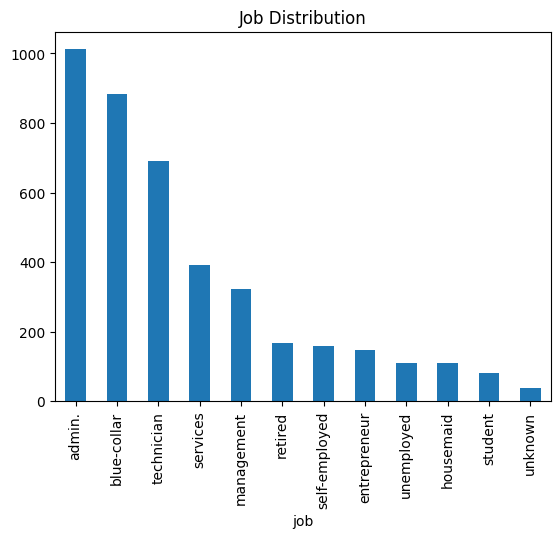

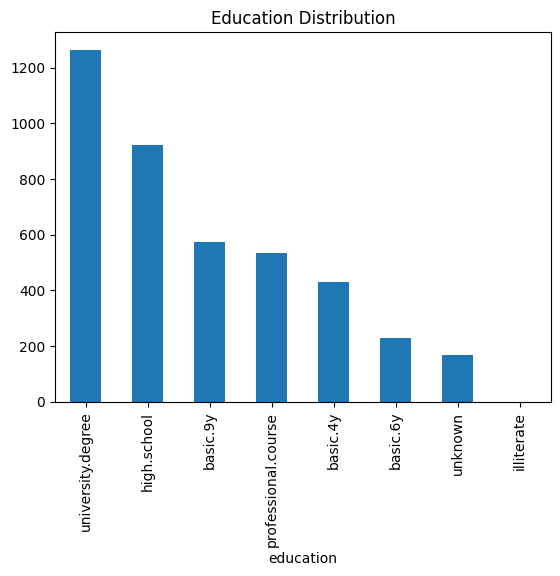

In [56]:
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution")
plt.show()

df["education"].value_counts().plot(kind="bar")
plt.title("Education Distribution")
plt.show()

Special Consideration: duration

The variable `duration` represents the length of the phone call. This information is only known after the call has taken place. Since the objective is to predict subscription at the time of contact, using `duration` would introduce data leakage. Therefore, this feature must be removed before model training.

Section 3: removing leakange and data splitting

In [57]:
df = df.drop(columns=["duration"])
df.shape

(4119, 20)

In [58]:
X = df.drop("y", axis=1)
y = df["y"]

In [59]:
from sklearn.model_selection import train_test_split

# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# Second split: 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (2471, 19)
Validation shape: (824, 19)
Test shape: (824, 19)


Data Splitting Strategy

The dataset was split into training (60%), validation (20%), and test (20%) sets. Stratified splitting was used to preserve the class distribution of the target variable (`y`) in all subsets. This is necessary because the dataset is imbalanced, and random splitting without stratification could produce subsets with distorted class proportions. The split is performed before any preprocessing steps such as encoding, scaling, resampling, or feature selection. This prevents data leakage, since transformations that learn parameters from the data must only be fitted on the training set.

section 4: handling missing values

In [60]:
X_train.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [61]:
for col in X_train.select_dtypes(include="object").columns:
    print(col, (X_train[col] == "unknown").sum())

job 20
marital 7
education 104
default 492
housing 55
loan 55
contact 0
month 0
day_of_week 0
poutcome 0


missing Values Handling

There are no explicit missing values (NaN) in the dataset. However, several categorical variables contain the category "unknown", which represents implicit missing information. We choose to keep "unknown" as its own category rather than removing those observations because:
- Removing them would reduce the dataset size
- The fact that information is missing may itself carry predictive value
- One-hot encoding can handle this category naturally.

No imputation is performed at this stage.

section 5: feature selection

In [62]:
X_train.nunique()

,0
age,64
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


Low-Variance Features:

No feature in the training set has only one unique value. Therefore, no feature was removed due to zero variance.

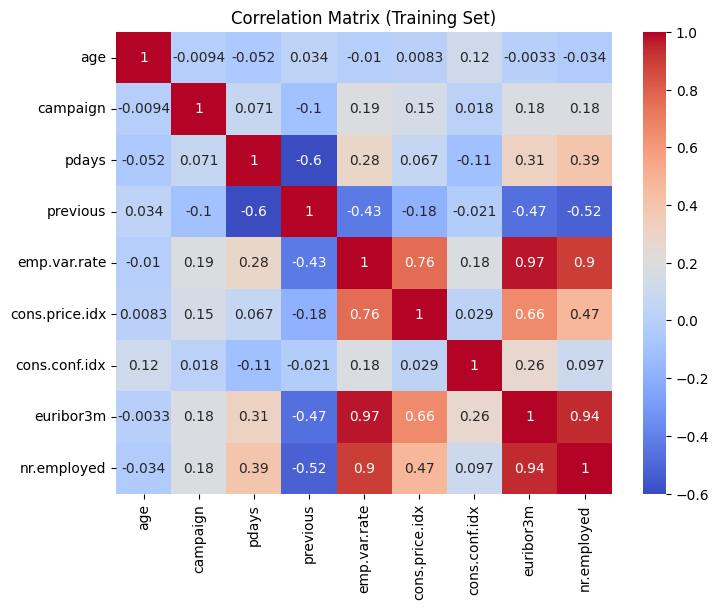

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Training Set)")
plt.show()

Multicollinearity Analysis

The initial correlation matrix revealed very strong correlations between the macroeconomic variables:

- emp.var.rate
- euribor3m
- nr.employed

Since correlations above 0.9 indicate strong multicollinearity, keeping all of these variables could negatively affect model stability, especially for Logistic Regression.

To reduce redundancy and improve interpretability, emp.var.rate and nr.employed were removed. The variable euribor3m was retained as a representative macroeconomic indicator.

In [64]:
X_train = X_train.drop(columns=["emp.var.rate", "nr.employed"])
X_val = X_val.drop(columns=["emp.var.rate", "nr.employed"])
X_test = X_test.drop(columns=["emp.var.rate", "nr.employed"])

Section 6: encoding and scaling


In [65]:
categorical_cols = X_train.select_dtypes(include="object").columns
numerical_cols = X_train.select_dtypes(exclude="object").columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')
Numerical: Index(['age', 'campaign', 'pdays', 'previous', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m'],
      dtype='object')


In [66]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)], remainder="passthrough")

In [67]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

Encoding and Scaling

Categorical variables were encoded using OneHotEncoder. The encoder was fitted only on the training set to prevent data leakage.

Numerical variables were scaled using StandardScaler, again fitted only on the training data. Scaling is particularly important for Logistic Regression, as it ensures that coefficients are not disproportionately influenced by variables with larger magnitudes.

Section 7: handling class imbalance

In [69]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())


Before SMOTE: y
no     2200
yes     271
Name: count, dtype: int64
After SMOTE: y
no     2200
yes    2200
Name: count, dtype: int64


Handling Class Imbalance

The dataset is imbalanced, with significantly more "no" observations than "yes".

To address this imbalance, SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training set.

SMOTE was applied:
- After scaling,
- Only on the training data,
- After the train/validation/test split.

Applying SMOTE before splitting would cause data leakage, since synthetic samples would influence validation and test sets.

The validation and test sets remain untouched to ensure unbiased model evaluation.

Section 8: model training

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=5000)

model.fit(X_train_resampled, y_train_resampled)

y_val_pred = model.predict(X_val_scaled)

print(confusion_matrix(y_val, y_val_pred))
print("\n")
print(classification_report(y_val, y_val_pred))

[[616 118]
 [ 37  53]]


              precision    recall  f1-score   support

          no       0.94      0.84      0.89       734
         yes       0.31      0.59      0.41        90

    accuracy                           0.81       824
   macro avg       0.63      0.71      0.65       824
weighted avg       0.87      0.81      0.84       824



In [71]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_scaled, y_train)

y_val_dummy = dummy.predict(X_val_scaled)

print(confusion_matrix(y_val, y_val_dummy))
print("\n")
print(classification_report(y_val, y_val_dummy))

[[734   0]
 [ 90   0]]


              precision    recall  f1-score   support

          no       0.89      1.00      0.94       734
         yes       0.00      0.00      0.00        90

    accuracy                           0.89       824
   macro avg       0.45      0.50      0.47       824
weighted avg       0.79      0.89      0.84       824



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
y_test_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_test_pred))
print("\n")
print(classification_report(y_test, y_test_pred))

[[591 143]
 [ 39  51]]


              precision    recall  f1-score   support

          no       0.94      0.81      0.87       734
         yes       0.26      0.57      0.36        90

    accuracy                           0.78       824
   macro avg       0.60      0.69      0.61       824
weighted avg       0.86      0.78      0.81       824



On the unseen test set, the Logistic Regression model achieved:

Accuracy: 78%

Recall for the minority class ("yes"): 57%

Precision for "yes": 26%

The recall remains stable compared to validation performance (59% → 57%), indicating good generalization and no significant overfitting.

Although precision is moderate, the model successfully identifies more than half of potential subscribers, which is valuable in a marketing context where missing interested customers is costly.

Compared to the Zero Rule baseline (which achieved 0% recall for "yes"), the trained model provides substantial predictive improvement.